# **Loading Packages**

In [142]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# **Load Dataset**

In [143]:
data = pd.read_csv(r'E:\Assignments\Evaluation\credit_card_train.csv')

print(data.head())

print(data.columns.tolist())

   Num_Children  Gender  Income Own_Car Own_Housing Credit_Card_Issuing
0             1    Male   40690      No         Yes              Denied
1             2  Female   75469     Yes          No              Denied
2             1    Male   70497     Yes         Yes            Approved
3             1    Male   61000      No          No              Denied
4             1    Male   56666     Yes         Yes              Denied
['Num_Children', 'Gender', 'Income', 'Own_Car', 'Own_Housing', 'Credit_Card_Issuing']


# **1. Data Preprocessing**

In [144]:
print("missing values:")
print(data.isnull().sum())

# mapped 'Approved' to 1 and 'Denied' to 0 because using LabelEncoder reverse the values in 'Approved' to 0 and 'Denied' to 1
data['Credit_Card_Issuing'] = data['Credit_Card_Issuing'].map({'Approved': 1, 'Denied': 0})

# making sure the endcoding succeeded
print("\nUnique values in 'Credit_Card_Issuing' after encoding:")
print(data['Credit_Card_Issuing'].unique())

# Encoding the categorical features
categorical_features = ['Gender', 'Own_Car', 'Own_Housing']

# Will be used to asses the fairness of the model
label_encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# Scaling features for 'Income' and 'Num_Children'
numerical_features = ['Income', 'Num_Children']
scaler = StandardScaler()
data[numerical_features] = scaler.fit_transform(data[numerical_features])

data.head()

missing values:
Num_Children           0
Gender                 0
Income                 0
Own_Car                0
Own_Housing            0
Credit_Card_Issuing    0
dtype: int64

Unique values in 'Credit_Card_Issuing' after encoding:
[0 1]


,Num_Children,Gender,Income,Own_Car,Own_Housing,Credit_Card_Issuing
0,-0.709499,1,-1.386510,0,1,0
1,-0.000633,0,0.128553,1,0,0
2,-0.709499,1,-0.088040,1,1,1
3,-0.709499,1,-0.501754,0,0,0
4,-0.709499,1,-0.690554,1,1,0


# **2. Exploratory Data Analysis**


Descriptive statistics:
       Num_Children         Gender        Income        Own_Car  \
count  4.000000e+05  400000.000000  4.000000e+05  400000.000000   
mean   2.703615e-17       0.500737  8.339107e-17       0.700937   
std    1.000001e+00       0.500000  1.000001e+00       0.457848   
min   -1.418366e+00       0.000000 -1.852194e+00       0.000000   
25%   -7.094993e-01       0.000000 -8.356176e-01       0.000000   
50%   -6.326635e-04       1.000000 -1.921100e-02       1.000000   
75%    7.082340e-01       1.000000  7.907048e-01       1.000000   
max    6.379167e+00       1.000000  2.068396e+00       1.000000   

         Own_Housing  Credit_Card_Issuing  
count  400000.000000        400000.000000  
mean        0.401295             0.386748  
std         0.490161             0.487006  
min         0.000000             0.000000  
25%         0.000000             0.000000  
50%         0.000000             0.000000  
75%         1.000000             1.000000  
max         1.00000

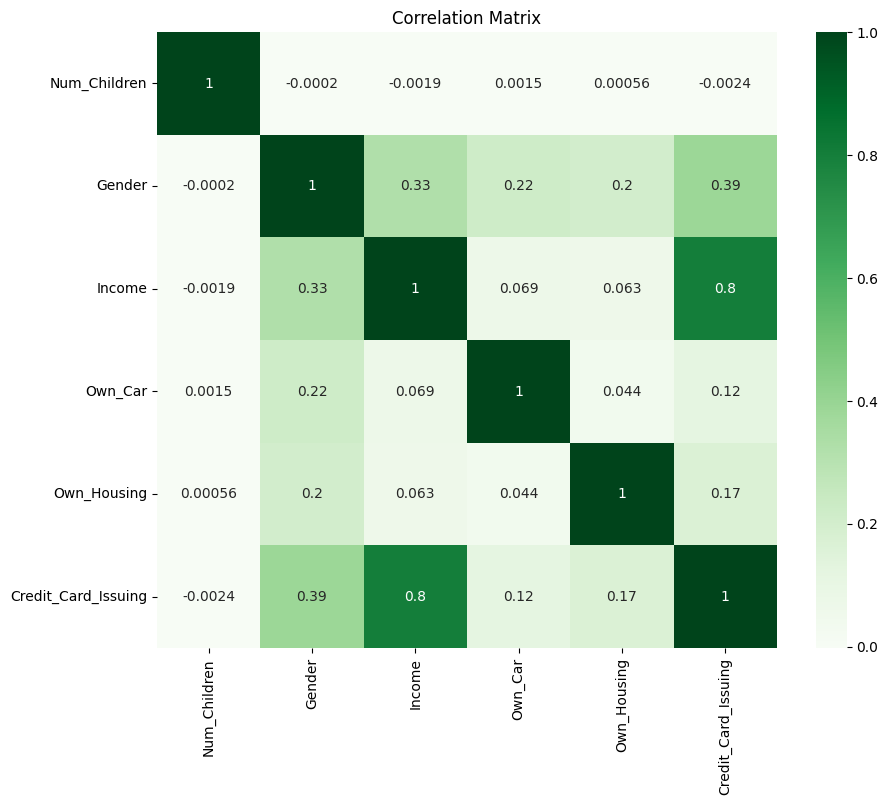

In [145]:
print("\nDescriptive statistics:")
print(data.describe())

# Correlation matrix
corr_matrix = data.corr()
print("\nCorrelation matrix:")
print(corr_matrix)

# Plotting HeatMap for the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='Greens')
plt.title('Correlation Matrix')
plt.show()

# **3. Feature Selection and Model Selection and Training**

In [146]:
features = ['Num_Children', 'Gender', 'Income', 'Own_Car', 'Own_Housing']
X = data[features]
y = data['Credit_Card_Issuing']

In [147]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Log Reg model
logreg = LogisticRegression(max_iter=1000, solver='liblinear')

# Using Grid Search for parameters tuning
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
len_param = len(param_grid['C'])

grid_search = GridSearchCV(
    logreg, param_grid, cv=len_param, scoring='accuracy'
)
grid_search.fit(X_train, y_train)

# Best model
best_logreg = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)

Best parameters: {'C': 1}


# **5. Performance Evaluation**


Performance Metrics:
Accuracy: 0.972575
Precision: 0.9648946840521565
Recall: 0.9641460023924219
F1-Score: 0.9645201979365439
AUC-ROC: 0.9979379385136005

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     49069
           1       0.96      0.96      0.96     30931

    accuracy                           0.97     80000
   macro avg       0.97      0.97      0.97     80000
weighted avg       0.97      0.97      0.97     80000



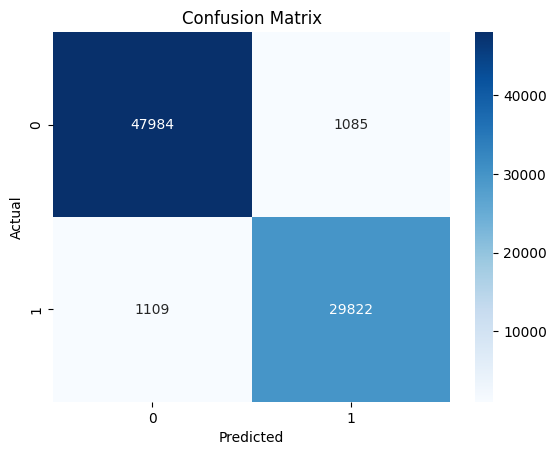

In [148]:
y_pred = best_logreg.predict(X_test)

# performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, best_logreg.predict_proba(X_test)[:, 1])

print("\nPerformance Metrics:")
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")
print(f"AUC-ROC: {auc}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# HeatMap for Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# **6. Fairness Considerations**

In [149]:
# As we said before it's cruical to make sure that the model isn't bias for a label on another
# Checking the fairness for bias in 'Gender'
gender_groups = X_test['Gender'].unique()

for gender_code in gender_groups:
    # We encoded the gender as 1 and 0 so we inverse transform to get the original gender label [Male, Female]
    gender_label = label_encoders['Gender'].inverse_transform([gender_code])[0]
    idx = X_test['Gender'] == gender_code
    group_y_test = y_test[idx]
    group_y_pred = y_pred[idx]
    group_accuracy = accuracy_score(group_y_test, group_y_pred)
    group_precision = precision_score(group_y_test, group_y_pred)
    group_recall = recall_score(group_y_test, group_y_pred)
    group_f1 = f1_score(group_y_test, group_y_pred)
    print(f"\nPerformance for Gender '{gender_label}':")
    print(f"Accuracy: {group_accuracy}")
    print(f"Percision: {group_precision}")
    print(f"Recall: {group_recall}")  
    print(f"F1: {group_f1}")

    selection_rate = sum(y_pred[X_test['Gender'] == gender_code]) / sum(X_test['Gender'] == gender_code)
    print(f'The Model Selection Rate for {gender_label} = {selection_rate}')


Performance for Gender 'Male':
Accuracy: 0.9739206607433363
Percision: 0.9773421810879246
Recall: 0.9771715408118725
F1: 0.9772568535009604
The Model Selection Rate for Male = 0.5732949568264297

Performance for Gender 'Female':
Accuracy: 0.9712323635909602
Percision: 0.9292588426446694
Recall: 0.9269417778331879
F1: 0.9280988640619149
The Model Selection Rate for Female = 0.19980022474715944


In [150]:
# Calculating actual approval rates in the dataset
male_code = label_encoders['Gender'].transform(['Male'])[0]
female_code = label_encoders['Gender'].transform(['Female'])[0]

actual_approval_rate_male = y_train[X_train['Gender'] == male_code].mean()
actual_approval_rate_female = y_train[X_train['Gender'] == female_code].mean()

print(f"Actual approval rate for Males: {actual_approval_rate_male}")
print(f"Actual approval rate for Females: {actual_approval_rate_female}")


Actual approval rate for Males: 0.5746975177747287
Actual approval rate for Females: 0.19805211073531254


In [151]:
# Count by gender and approval status
gender_approval_counts = data.groupby(['Gender', 'Credit_Card_Issuing']).size().unstack()
print(gender_approval_counts)


Credit_Card_Issuing       0       1
Gender                             
0                    160063   39642
1                     85238  115057


### This means that the data itself is biased to a certain gender but the model isn't and that's due to the numbers provided above about the selection rate and actual selection rate. They are very similar in the values given.

# **7. Model Interpretability**


Model Coefficients:
        Feature  Coefficient
0  Num_Children    -0.011230
1        Gender     7.622083
2        Income    17.479262
3       Own_Car     2.309464
4   Own_Housing     5.344498


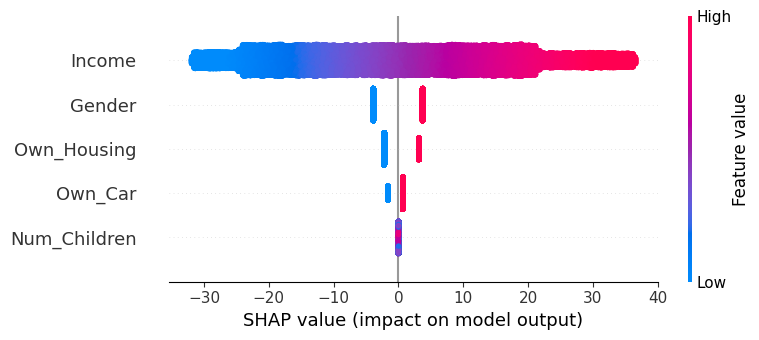

In [152]:
# Coefficient analysis
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': best_logreg.coef_[0]
})
print("\nModel Coefficients:")
print(coefficients)

# SHAP values
# Initialize SHAP
shap.initjs()

# Create the explainer
explainer = shap.LinearExplainer(best_logreg, X_train)
shap_values = explainer.shap_values(X_test)

# Plot the summary
shap.summary_plot(shap_values, X_test, feature_names=features)

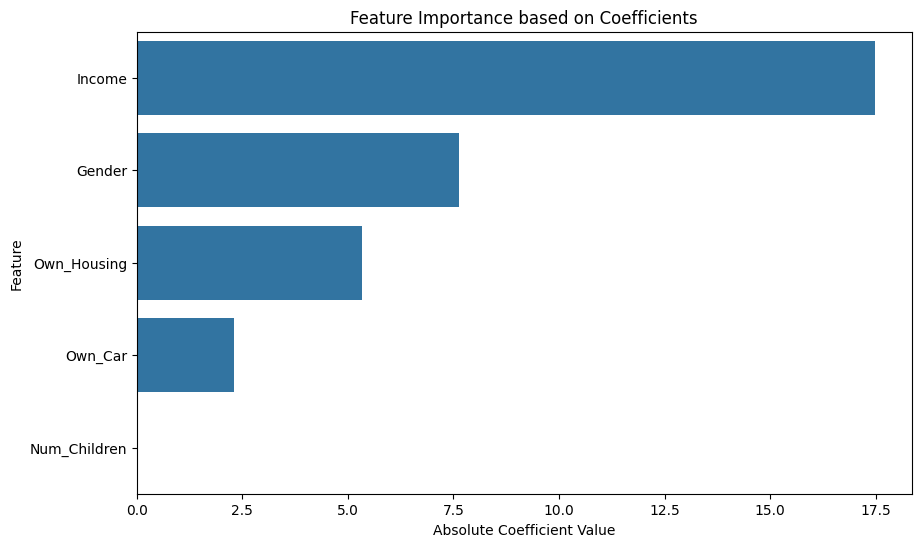

In [153]:
coefficients['Absolute_Coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='Absolute_Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Absolute_Coefficient', y='Feature', data=coefficients)
plt.title('Feature Importance based on Coefficients')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.show()


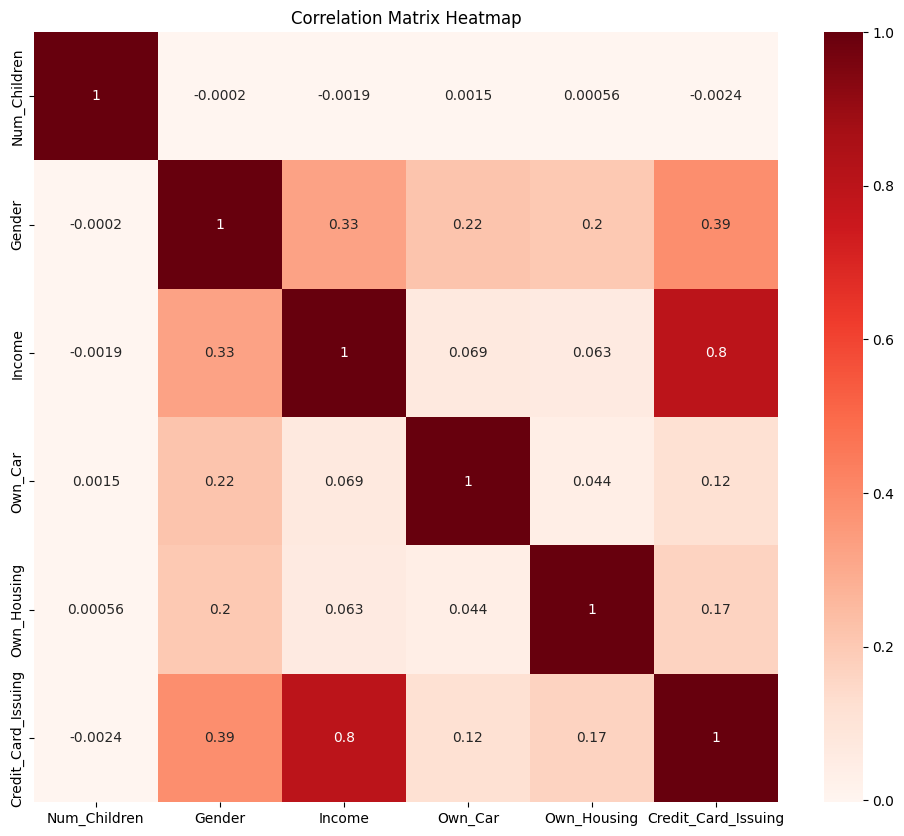

In [154]:
plt.figure(figsize=(12, 10))
corr_matrix = data.corr()
sns.heatmap(corr_matrix, annot=True, cmap='Reds')
plt.title('Correlation Matrix Heatmap')
plt.show()

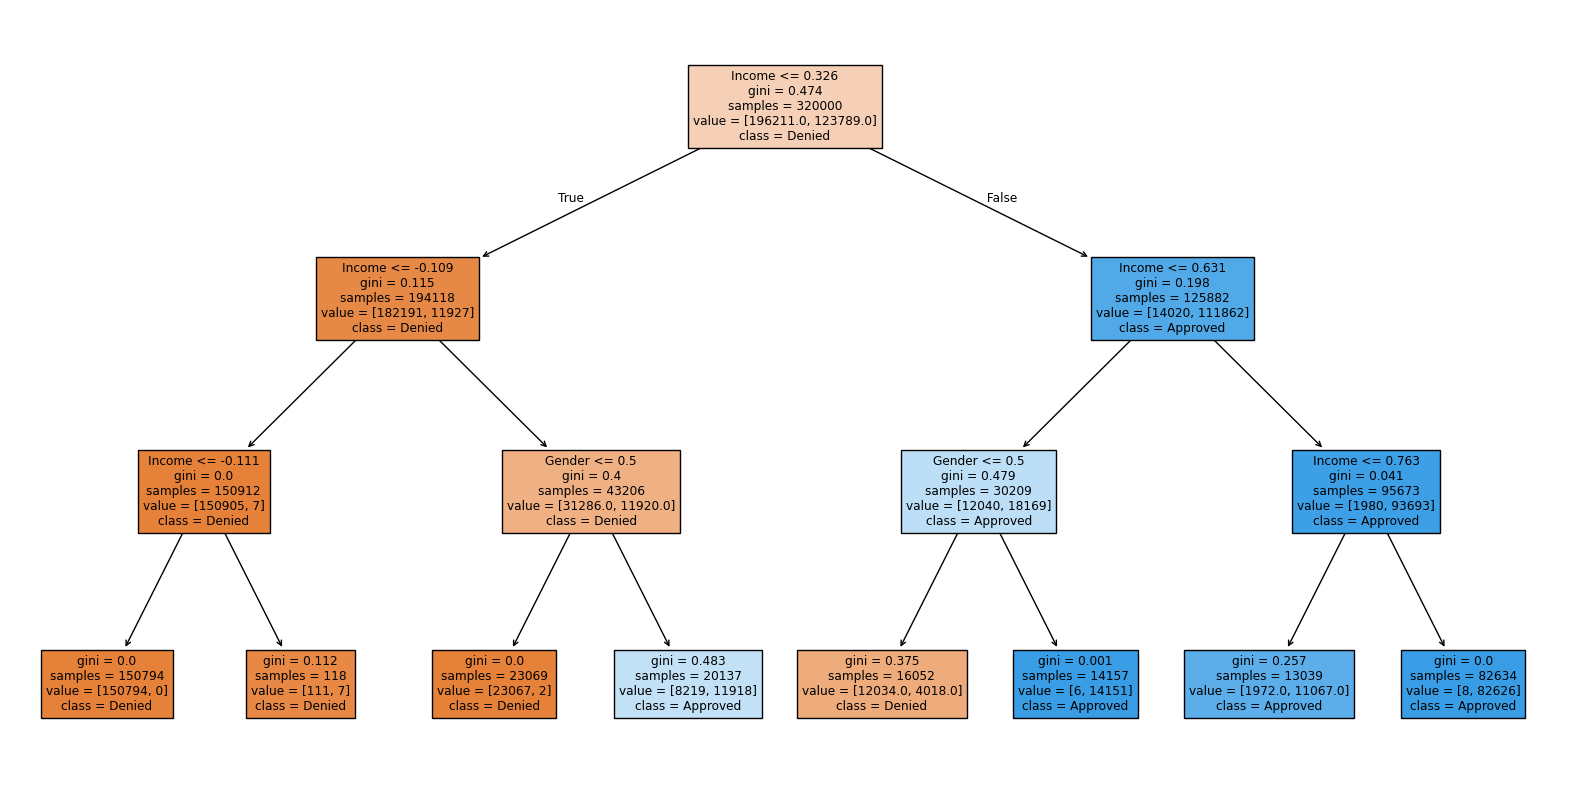

In [155]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Train a surrogate model
surrogate = DecisionTreeClassifier(max_depth=3)
surrogate.fit(X_train, best_logreg.predict(X_train))

# Plot the tree
plt.figure(figsize=(20, 10))
plot_tree(surrogate, feature_names=features, class_names=['Denied', 'Approved'], filled=True)
plt.show()


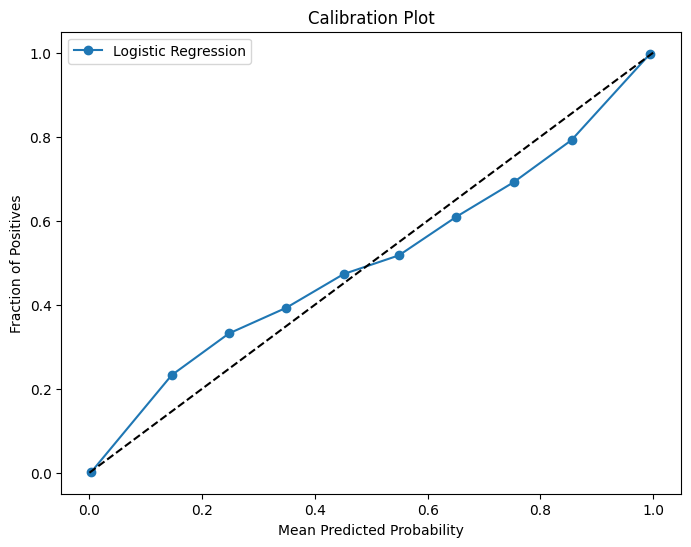

In [156]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, best_logreg.predict_proba(X_test)[:, 1], n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Logistic Regression')
plt.plot([0, 1], [0, 1], 'k--')  # Perfect calibration
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Plot')
plt.legend()
plt.show()


# **8. Applying the prediction function**

In [157]:
def predict_credit_approval(input_data):
    df = pd.DataFrame(input_data)
    
    for col in categorical_features:
        le = label_encoders[col]
        df[col] = le.transform(df[col])
    
    df[numerical_features] = scaler.transform(df[numerical_features])
    
    predictions = best_logreg.predict(df[features])
    
    return {"predictions": predictions.tolist()}

In [158]:
# Request Body Examples

request_body = {
    "Num_Children": [1],
    "Gender": ["Male"],
    "Income": [115078],
    "Own_Car": ["No"],
    "Own_Housing": ["Yes"]
} # Approved

# request_body = {
#     "Num_Children": [5],
#     "Gender": ["Female"],
#     "Income": [47506],
#     "Own_Car": ["No"],
#     "Own_Housing": ["No"]
# } # Denied

response = predict_credit_approval(request_body)

print("\nPredictions for the request:")
print(response)



Predictions for the request:
{'predictions': [1]}
